In [ ]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from src.utils import show_corr,remove_outliers_iqr,show_outliers
from src.data_loader import load_data
from src.features_extraction import build_features,add_galaxy_population_formula,add_spectral_type_formula

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [24]:
raw_path = r'..\data\raw'
train_path = os.path.join(raw_path,'train.csv')
test_path = os.path.join(raw_path,'test.csv')
org_dataset_path = os.path.join(raw_path,"star_classification.csv")

In [36]:
orig_df = load_data(org_dataset_path,is_org_dataset=True)
train_df = load_data(train_path)
test_df = load_data(test_path,False)

In [26]:
orig_df

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,0,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,0,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,0,0.116123
...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,0,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,0,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,0,0.143366
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,0,0.455040


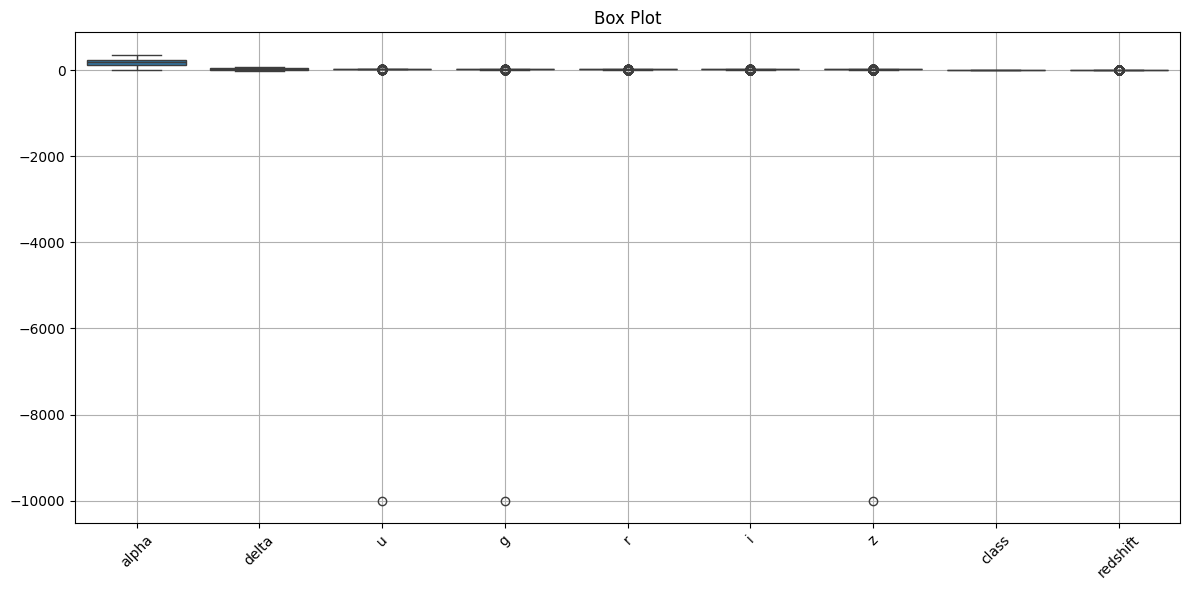

In [27]:
show_outliers(orig_df)

In [37]:
orig_df = remove_outliers_iqr(orig_df,orig_df.columns,10)

In [38]:
len(orig_df)

99999

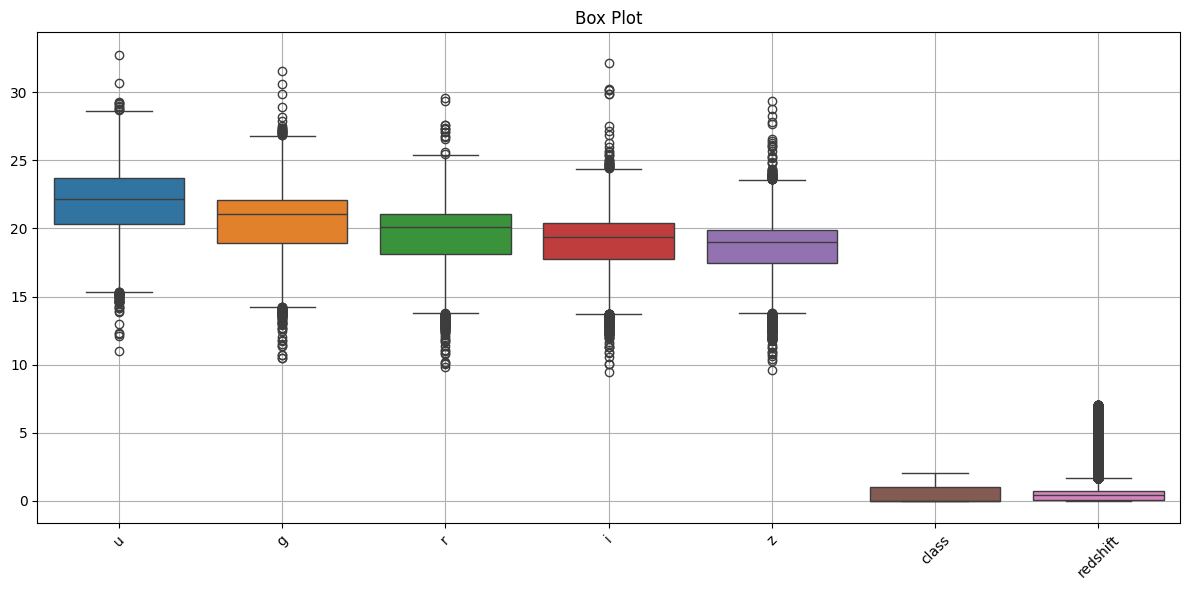

In [39]:
show_outliers(orig_df[orig_df.columns[2:]])

In [40]:
orig_df_FE = build_features(orig_df)

In [41]:
orig_df_FE = add_spectral_type_formula(orig_df_FE)
orig_df_FE = add_galaxy_population_formula(orig_df_FE)
orig_df_FE = pd.concat([orig_df_FE,pd.get_dummies(orig_df_FE[['spectral_type','galaxy_population']],dtype=int)],axis=1)
orig_df_FE.drop(['spectral_type','galaxy_population'],inplace=True,axis=1)

In [42]:
orig_df_FE.head()

,alpha,delta,u,g,r,i,z,class,redshift,color_ug,...,sky_y,sky_z,z_x_u_g,z_x_g_r,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0,0.634794,1.60352,...,0.589187,0.537221,1.017904,1.193596,0,0,1,0,0,1
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0,0.779136,1.94571,...,0.492354,0.519134,1.515973,0.192789,1,0,0,0,1,0
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,0,0.644195,2.59918,...,0.498590,0.581874,1.674377,1.323259,0,0,1,0,0,1
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,0,0.932346,-1.63974,...,-0.362575,-0.007031,-1.528804,2.018472,0,0,1,0,1,0
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,0,0.116123,1.85690,...,-0.236884,0.361362,0.215628,0.125739,0,0,1,0,0,1


In [4]:
train_df

,alpha,delta,u,g,r,i,z,redshift,class,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,1,0,1
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,1,0,1
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,0,0,0,1,0
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,0,1,0,1
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,0,0,0,1,0,1
577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,0,0,0,1,0,1
577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,0,0,0,1,0,1
577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,1,0,1,0,0,0


In [5]:
test_df

,alpha,delta,u,g,r,i,z,redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,0,1,0,0,1
1,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,0,0,1,0,1
2,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,0,1,0,0,0
3,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,0,1,0,0,1
4,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
247430,248.013903,49.533434,21.563545,21.716868,21.670791,21.265478,21.558618,1.214520,1,0,0,0,0
247431,226.823885,52.635936,21.434441,21.075412,20.778300,20.962333,21.010822,1.004950,1,0,0,0,0
247432,232.879335,44.948125,23.294670,22.336583,20.121142,19.405430,18.744581,0.269394,0,0,1,0,1
247433,351.396802,2.451824,20.882944,20.902010,20.222812,20.551737,20.278339,1.199392,0,1,0,0,0


In [6]:
train_df_FE = build_features(train_df)
test_df_FE = build_features(test_df)

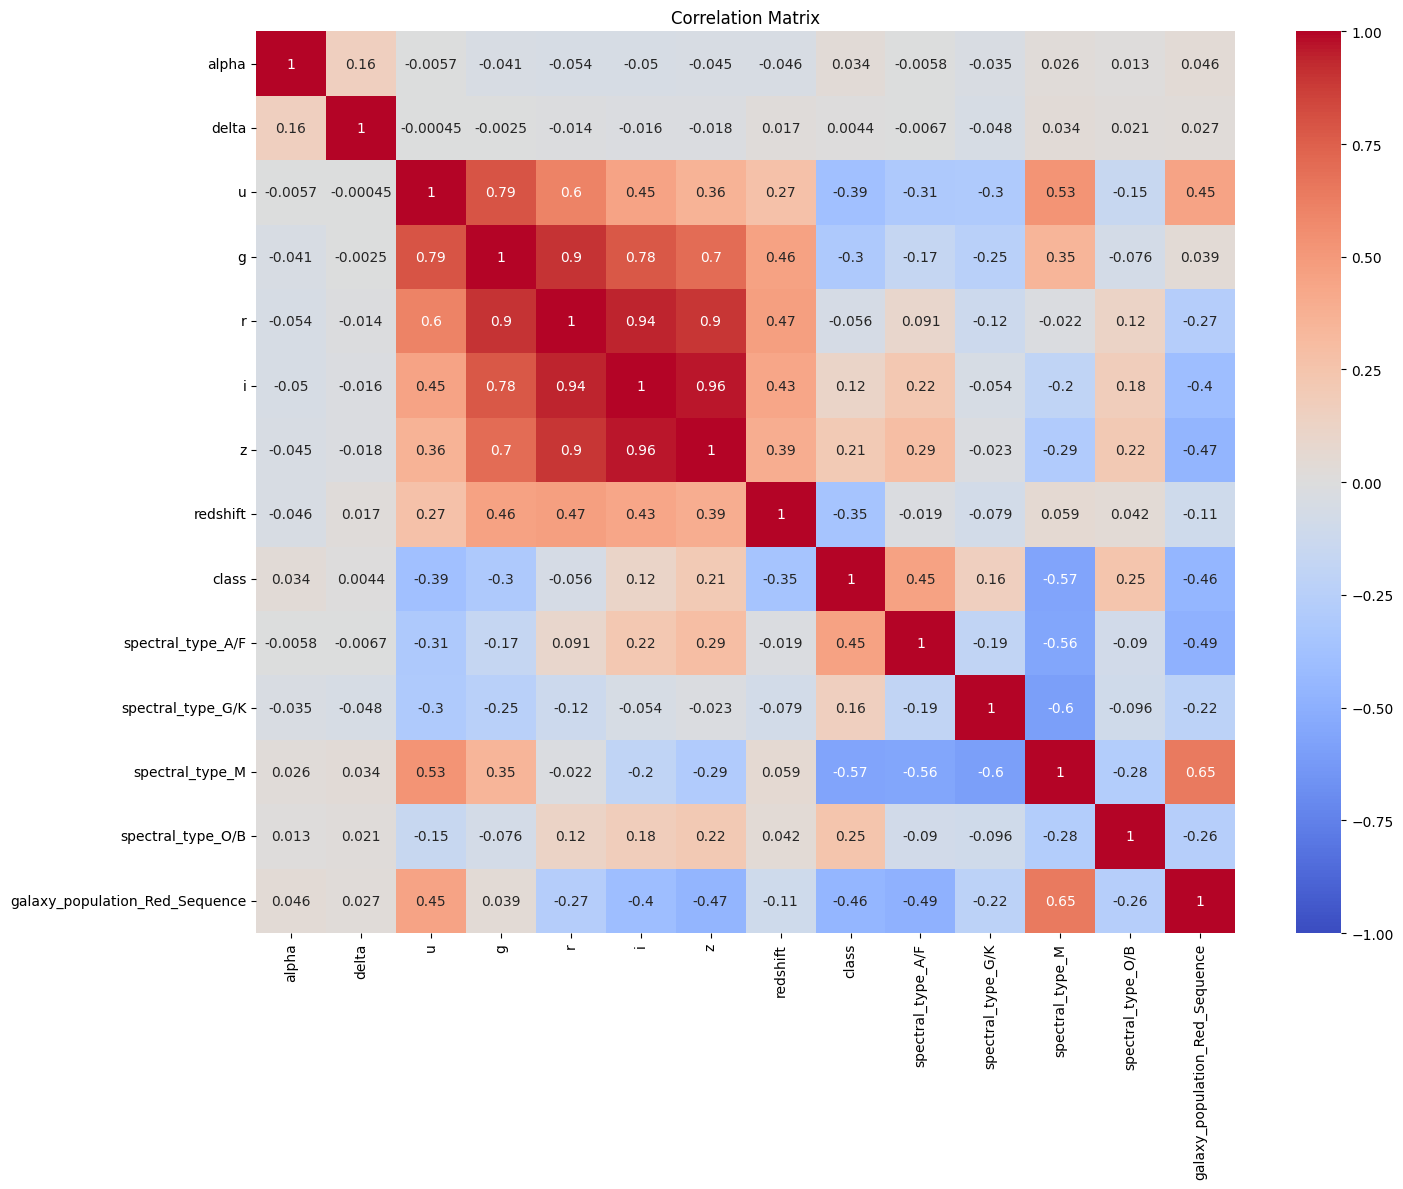

In [ ]:
# Before FE
show_corr(train_df)

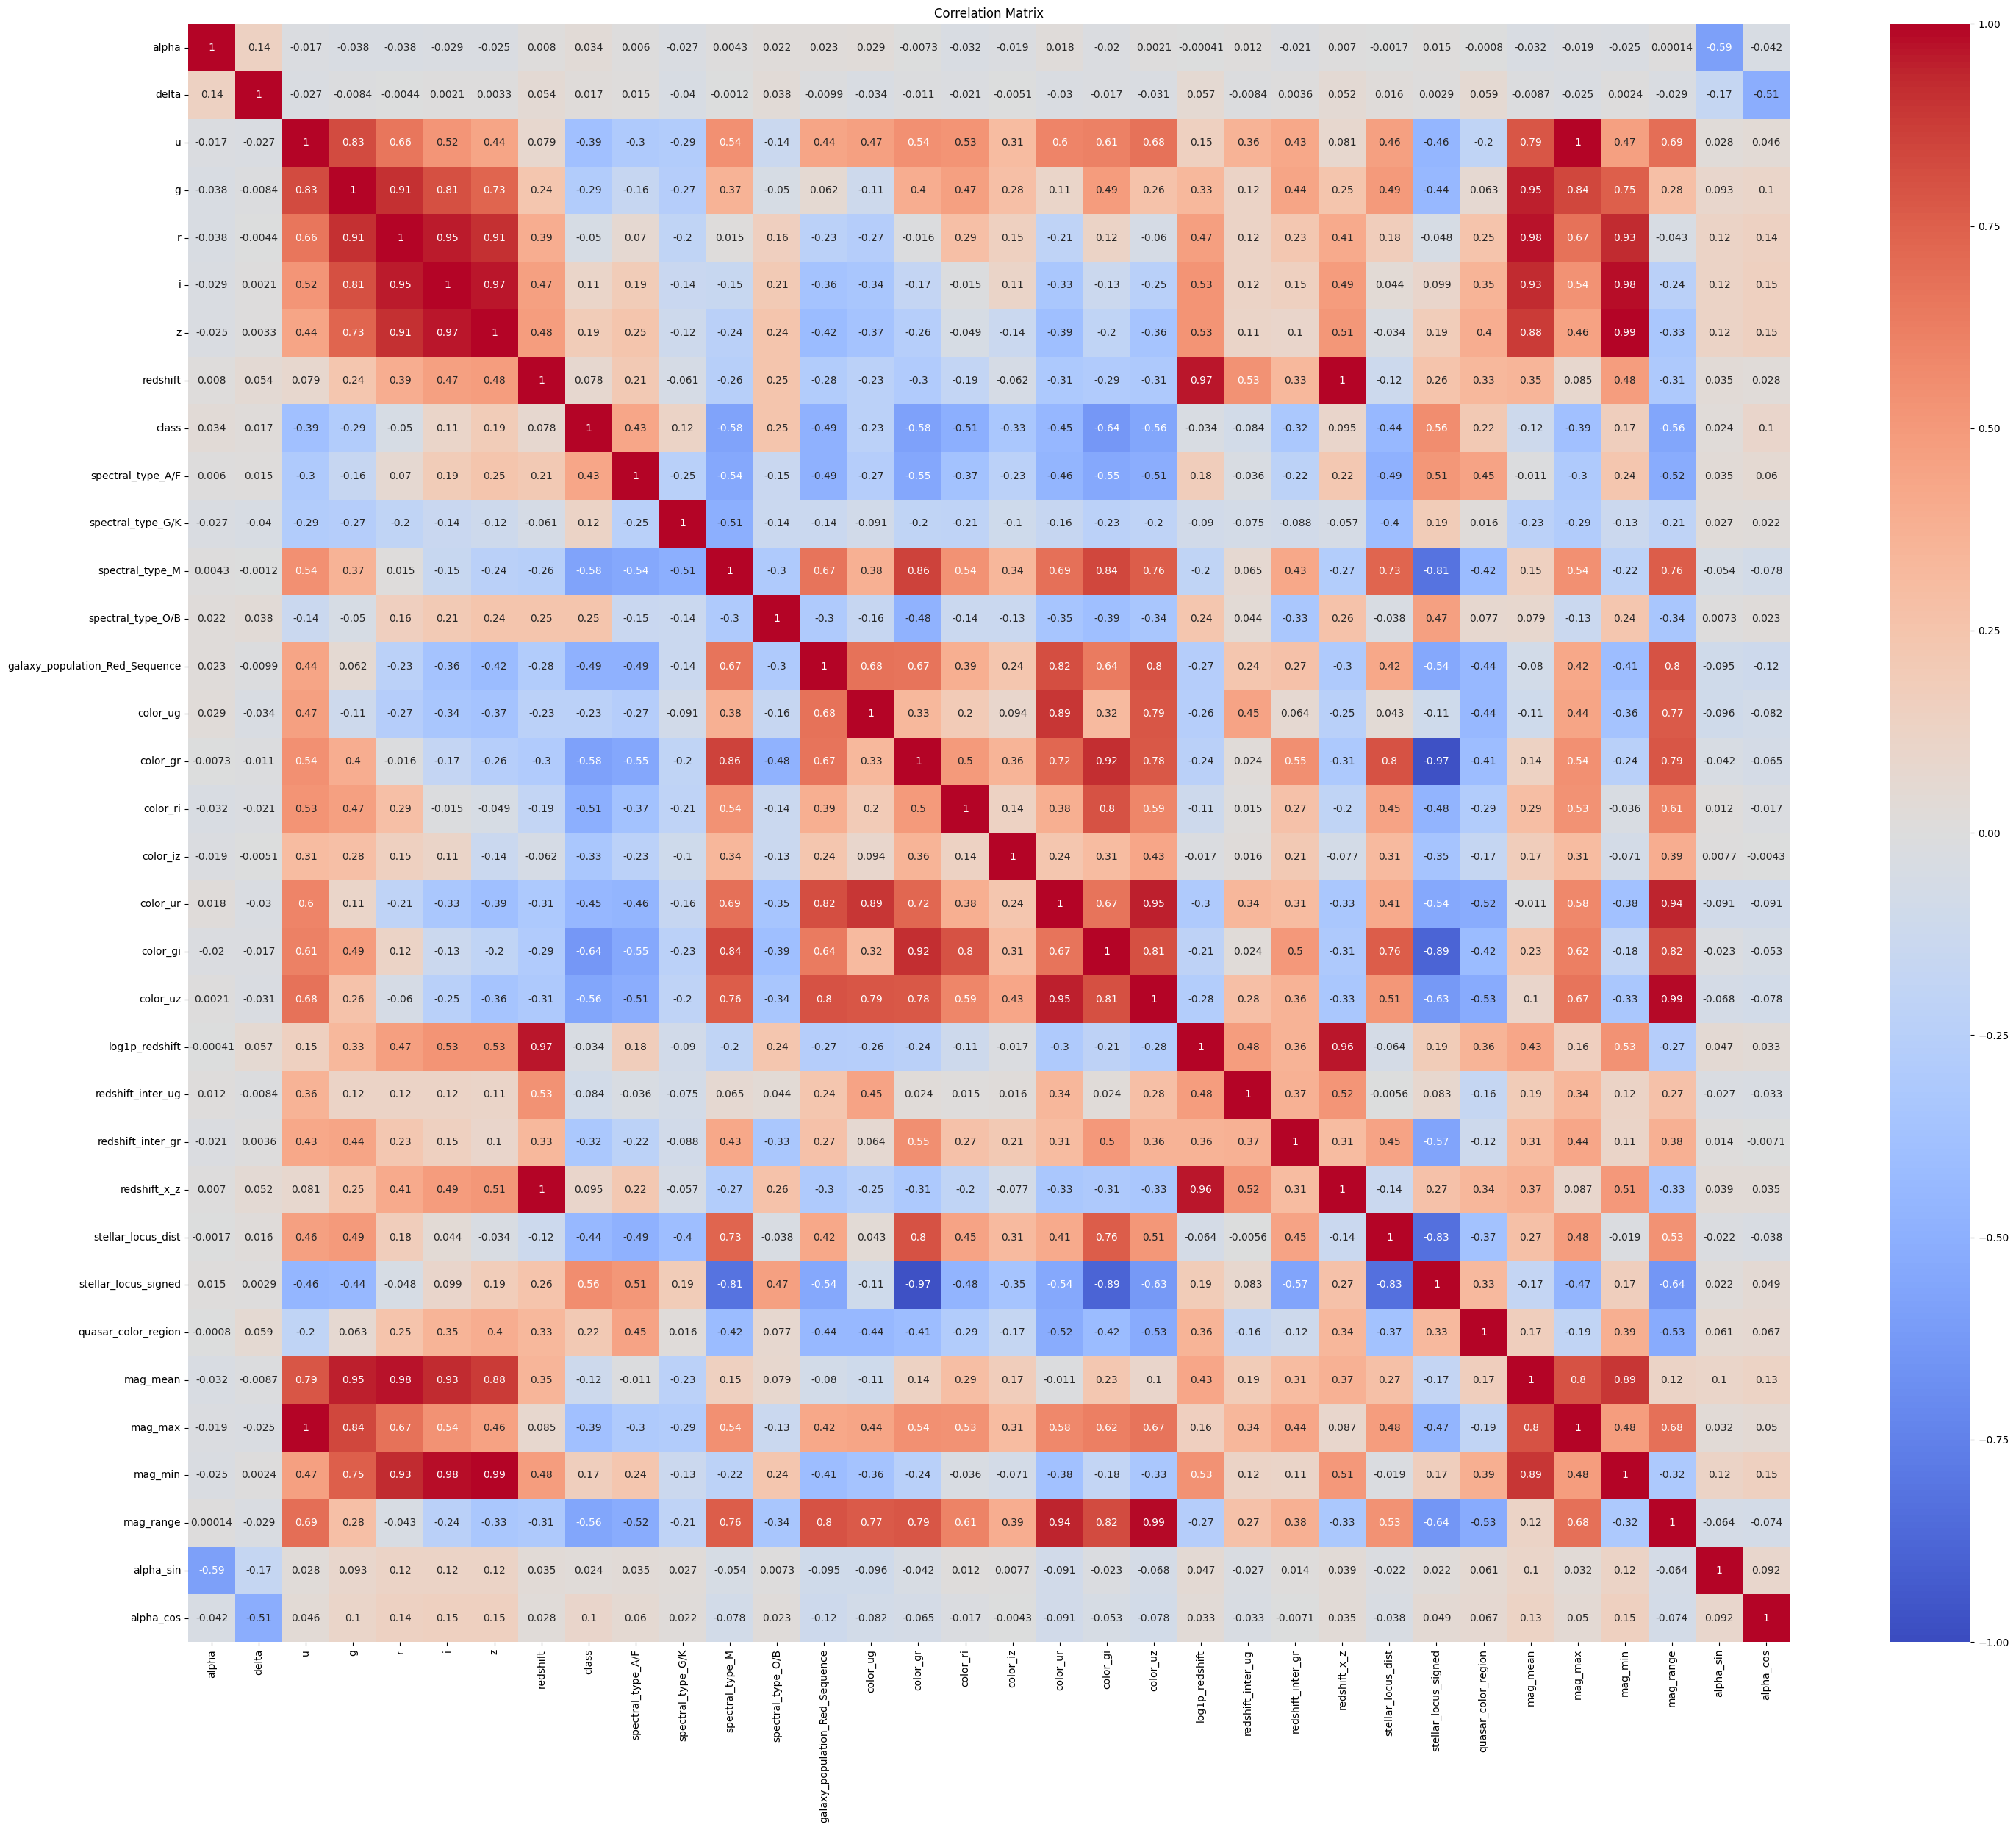

In [8]:
# FE Applied
show_corr(train_df_FE,h=30,w=25)

In [ ]:
train_df_FE.to_csv(r'..\data\processed\train_df_FE.csv')
test_df_FE.to_csv(r'..\data\processed\test_df_FE.csv')
orig_df_FE.to_csv(r'..\data\processed\df_orig_FE.csv')